In [30]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.stats as astro
import scipy 
import typing
import pandas as pd
from explorationplots import seyiheading_from_d
from AT_plots import cart2pola


In [23]:
testdirected = [90,95, 80, 70, 79, 180]
test_nondirected = [90, 180, 270, 360]

def go(ds:list):
    r = np.ones(len(ds))
    
    testrad = [np.deg2rad(i) for i in ds]
    
    
    fig = plt.figure(figsize=(10, 10)) #10, 10
    ax2 = fig.add_subplot(222,projection='polar')
    alphaval = 0.2
    
    max_r = max(r)
    
    ax2.scatter(ds, r, alpha=alphaval, s= 2,c=range(len(ds)), vmin=0, vmax=len(ds), cmap="gist_rainbow")
    
    
    mean_theta = np.array(testrad)
    mean_heading_theta = scipy.stats.circmean(mean_theta) # circ mean wants radians
    
    rayleigh_ans = astro.rayleightest(mean_theta) # astro rayleightest wants radians
    
    if rayleigh_ans <= 0.05: # if Rayleigh<=0.05 
        ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            ec='k', scale=1)# headings_end[:] headings_end[:]
    
    """print(f"rayle ans: {np.rad2deg(rayleigh_ans)}")
    
    ax2.scatter(rayleigh_ans, max_r, alpha=0.4, marker='$o$',s= 60, c= 'yellow') 
    ax2.quiver(rayleigh_ans,  # x
        max_r,      # y
        np.cos(rayleigh_ans),  # V   x
        np.sin(rayleigh_ans),    # U [0] y
        ec='y',)"""



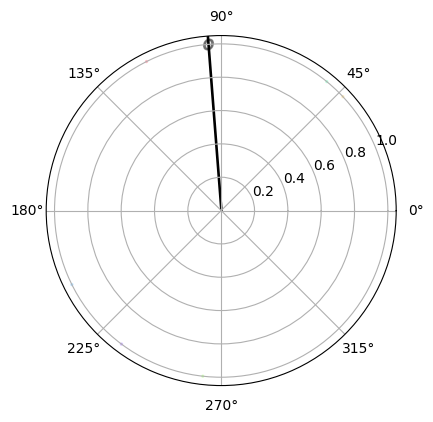

In [24]:
go(testdirected)

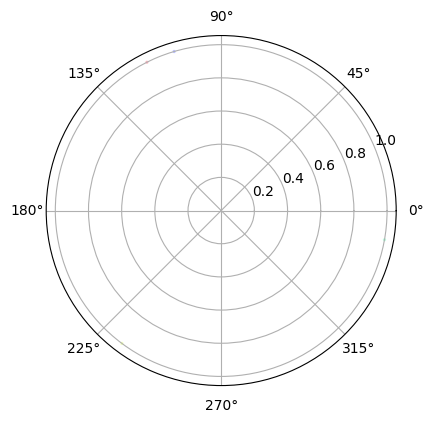

In [25]:
go(test_nondirected)

In [71]:
# x, y, id, index

testdict = {'index': [0,1,2,3,4,5], 'ID' : [123, 234, 345, 456, 567, 678], 'x': [[0, 2, 5, 3, 8, 12, 15, 18, 16, 20, 25, 28, 32, 35, 33, 38], [5, 7, 4, 9, 11, 8, 13, 16, 19, 17, 22, 25, 23, 28, 31, 29], [10, 12, 9, 14, 11, 16, 19, 21, 18, 24, 27, 25, 30, 33, 31, 35], [8, 6, 11, 9, 13, 16, 14, 18, 21, 19, 24, 27, 30, 28, 33, 36], [15, 17, 14, 19, 16, 21, 24, 22, 26, 29, 27, 32, 35, 33, 38, 41], [12, 10, 15, 13, 17, 20, 18, 23, 26, 24, 28, 31, 29, 34, 37, 35]], 'y' : [[0, 1, 4, 7, 5, 9, 12, 10, 15, 18, 21, 19, 23, 26, 29, 32], [3, 5, 8, 6, 10, 13, 11, 15, 12, 18, 16, 20, 23, 21, 25, 28], [2, 4, 7, 5, 9, 12, 10, 14, 17, 15, 19, 22, 20, 24, 27, 25], [6, 9, 7, 11, 8, 12, 15, 13, 17, 20, 18, 22, 19, 25, 23, 27], [8, 6, 10, 8, 12, 9, 13, 16, 14, 18, 21, 19, 23, 26, 24, 28], [12, 15, 13, 17, 14, 18, 21, 19, 23, 26, 24, 28, 31, 29, 33, 36]]}
print(testdict)
testdf = pd.DataFrame(testdict)

print(testdf)

{'index': [0, 1, 2, 3, 4, 5], 'ID': [123, 234, 345, 456, 567, 678], 'x': [[0, 2, 5, 3, 8, 12, 15, 18, 16, 20, 25, 28, 32, 35, 33, 38], [5, 7, 4, 9, 11, 8, 13, 16, 19, 17, 22, 25, 23, 28, 31, 29], [10, 12, 9, 14, 11, 16, 19, 21, 18, 24, 27, 25, 30, 33, 31, 35], [8, 6, 11, 9, 13, 16, 14, 18, 21, 19, 24, 27, 30, 28, 33, 36], [15, 17, 14, 19, 16, 21, 24, 22, 26, 29, 27, 32, 35, 33, 38, 41], [12, 10, 15, 13, 17, 20, 18, 23, 26, 24, 28, 31, 29, 34, 37, 35]], 'y': [[0, 1, 4, 7, 5, 9, 12, 10, 15, 18, 21, 19, 23, 26, 29, 32], [3, 5, 8, 6, 10, 13, 11, 15, 12, 18, 16, 20, 23, 21, 25, 28], [2, 4, 7, 5, 9, 12, 10, 14, 17, 15, 19, 22, 20, 24, 27, 25], [6, 9, 7, 11, 8, 12, 15, 13, 17, 20, 18, 22, 19, 25, 23, 27], [8, 6, 10, 8, 12, 9, 13, 16, 14, 18, 21, 19, 23, 26, 24, 28], [12, 15, 13, 17, 14, 18, 21, 19, 23, 26, 24, 28, 31, 29, 33, 36]]}
   index   ID                                                  x  \
0      0  123  [0, 2, 5, 3, 8, 12, 15, 18, 16, 20, 25, 28, 32...   
1      1  234  [5, 7, 4, 9,

In [72]:
# df_exploded = df.explode(['x', 'y']).reset_index(drop=True)

testdf_exploded = testdf.explode(['x', 'y']).reset_index(drop=True)
testdf_exploded['x'] = testdf_exploded['x'].astype(float)
testdf_exploded['y'] = testdf_exploded['y'].astype(float)

print(testdf_exploded)

    index   ID     x     y
0       0  123   0.0   0.0
1       0  123   2.0   1.0
2       0  123   5.0   4.0
3       0  123   3.0   7.0
4       0  123   8.0   5.0
..    ...  ...   ...   ...
91      5  678  31.0  28.0
92      5  678  29.0  31.0
93      5  678  34.0  29.0
94      5  678  37.0  33.0
95      5  678  35.0  36.0

[96 rows x 4 columns]


In [142]:
def create_Overlayed_polar_plot2(df_coordinates, max_len, title:str, pindex='frame', save =False, xname='x', yname='y', bkgrnd=None, step =10, foodcentered =False):
    # create plot base
    fig = plt.figure(figsize=(10, 10)) #10, 10
    ax2 = fig.add_subplot(222,projection='polar')
    alphaval = 0.2

    ids = np.unique(df_coordinates['ID'])
    longestdf = {'id': 0, 'length': 0, 'scat_ele' :0}
    final_heading_list = []
    cart_final_heading_list = []
    max_r = 0
    
    if bkgrnd is not None:
        implot = ax1.imshow(bkgrnd)

    for id in ids:
        newdf = df_coordinates[df_coordinates['ID']== id]
        df_len = len(newdf)
        
        
        _x = np.array(newdf[xname])
        _y =  np.array(newdf[yname])
        dx_ = newdf[xname].diff(periods=1)
        dy_ = newdf[yname].diff(periods=1)
        

        if foodcentered:
            newx = np.array(newdf['new_x'])
            newy = np.array(newdf['new_y'])
            
            theta, r = cart2pola(newx, newy)

        theta, r = cart2pola(_x, _y)
        final_heading_list.append(theta[-1])
        
        if r[-1] > max_r:
            max_r = r[-1]

            

        
        # Plot the points
        scatter2 = ax2.scatter(theta, r, alpha=alphaval, s= 2,c=range(df_len), vmin=0, vmax=max_len, cmap="gist_rainbow") #nipy_spectral

        ax2.grid(False)
    
        # plot final pos

        ax2.scatter(theta[-1], r[-1], alpha=alphaval, marker='$o$',s= 60, c= 'blue') 


        ax2.scatter(theta[0], r[0], alpha=alphaval, marker='$o$',s= 60, c= 'red') 

        
        if df_len > longestdf['length']: # ensure that legend is created once
            longestdf['length'] = df_len
            longestdf['scat_ele'] = scatter2.legend_elements()

    print(f"final headings:  {final_heading_list}")
    final_heading_array = np.array(final_heading_list)
    rayleigh_ans = astro.rayleightest(final_heading_array) # astro rayleightest wants radians
    if rayleigh_ans <= 0.05:
        mean_heading_theta = scipy.stats.circmean(final_heading_array) # circ mean wants radians
        print(f"mean theta type {type(mean_heading_theta)} mean: {mean_heading_theta}")

        print(f" mean head rad {mean_heading_theta}")
    

        ax2.scatter(mean_heading_theta, max_r, alpha=0.4, marker='$o$',s= 60, c= 'k') 
        ax2.quiver(0,  # x mean_heading_theta
            0,      # y max_r
            np.cos(mean_heading_theta),  # V
            np.sin(mean_heading_theta),    # U [0]
            
            ec='k', scale=1)# 

    legend2 = fig.legend(*longestdf['scat_ele'],
                loc="upper right", title="frames")
    fig.add_artist(legend2)
    fig.suptitle(title)

    if save == True:
        plt.savefig(title)
    
    plt.show()

In [73]:
print(testdf_exploded[testdf_exploded['x']==0])

print(testdf_exploded[testdf_exploded['y']==0])

   index   ID    x    y
0      0  123  0.0  0.0
   index   ID    x    y
0      0  123  0.0  0.0


final headings:  [0.6998928697192437, 0.7678561033400458, 0.6202494859828215, 0.6435011087932845, 0.5991753229863069, 0.7994817392203084]
mean theta type <class 'numpy.float64'> mean: 0.6883382720645876
 mean head rad 0.6883382720645876


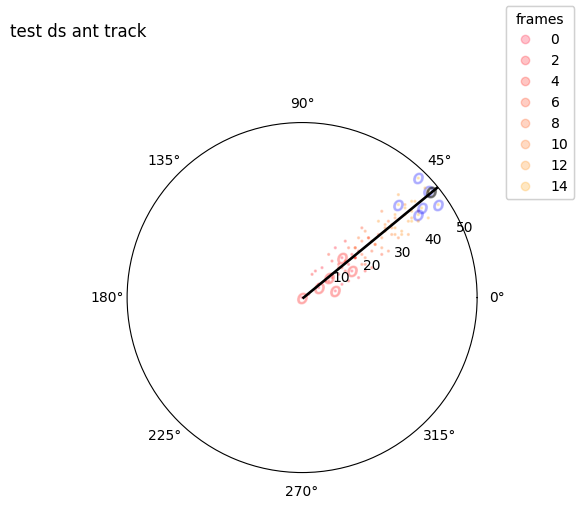

In [143]:
create_Overlayed_polar_plot(testdf_exploded, max_len=len(testdf_exploded), title ='test ds ant track')

final headings:  [0.6998928697192437, 0.7678561033400458, 0.6202494859828215, 0.6435011087932845, 0.5991753229863069, 0.7994817392203084]
mean theta type <class 'numpy.float64'> mean: 0.6883382720645876
 mean head rad 0.6883382720645876


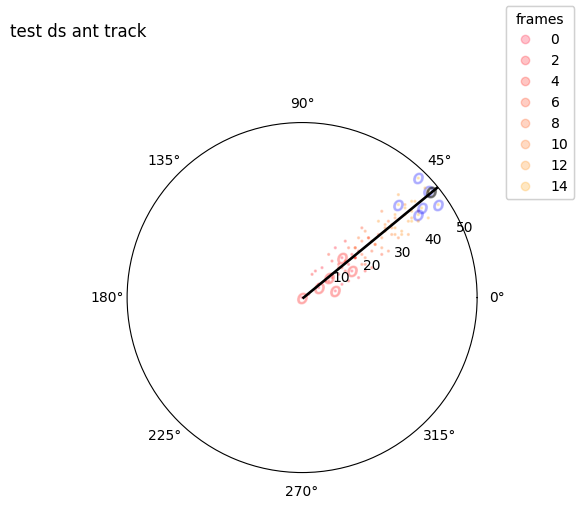

In [144]:
create_Overlayed_polar_plot(testdf_exploded, max_len=len(testdf_exploded), title ='test ds ant track', seyiornay=True)